In [72]:
import pypsa

network = pypsa.Network("../solved_networks/tyndp2024_network_2030_slack_optimized_26.nc")
print(f"Loaded: {len(network.buses)} buses, {len(network.generators)} generators")
model_price = network.buses_t.marginal_price["DE00"]


INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks


Loaded: 55 buses, 559 generators


In [73]:
import pandas as pd

XLSX = "../data/tyndp2024/MMStandardOutputFile_NT2030_Plexos_CY2009_2.5_v40 3.xlsx"

# Row 14 (0-indexed=13) is the header row with column names
# Data starts at row 15 (0-indexed=14)
df_raw = pd.read_excel(
    XLSX,
    sheet_name="Hourly Market Data",
    header=13,
    usecols="B,UF",
    engine="openpyxl",
)

# Rename columns clearly
df_raw.columns = ["timestamp_str", "marginal_cost"]

# Drop any NaN rows
df_raw = df_raw.dropna(subset=["timestamp_str", "marginal_cost"])

print(f"Shape: {df_raw.shape}")
print(f"Timestamp format sample: {df_raw['timestamp_str'].iloc[0]}")
print(df_raw.head())


Shape: (8735, 2)
Timestamp format sample: 01JAN01:00
  timestamp_str  marginal_cost
0    01JAN01:00         87.010
1    01JAN02:00         87.010
2    01JAN03:00         87.010
3    01JAN04:00         87.010
4    01JAN05:00         87.018


In [74]:
import matplotlib.pyplot as plt

# Parse timestamps — format is e.g. "01JAN01:00" → day=01, month=JAN, hour=01:00
# Add year 2030 to make full datetime
df = df_raw.copy()
df["timestamp"] = pd.to_datetime(
    "2030-" + df["timestamp_str"].str[:5],   # "2030-01JAN" won't work — use strptime
    format="%Y-%d%b",                         # won't work directly either
    errors="coerce"
)

# Fallback: manual parse using strptime approach
df["timestamp"] = pd.to_datetime(
    df["timestamp_str"].apply(
        lambda s: f"2030-{s[:5].replace(s[2:5], s[2:5].capitalize())}"
    ),
    format="%Y-%d%b",
    errors="coerce"
)

# Check parse quality
n_bad = df["timestamp"].isna().sum()
print(f"Parsed OK: {len(df) - n_bad} / {len(df)}  |  Failed: {n_bad}")
print(df[["timestamp_str", "timestamp", "marginal_cost"]].head(5))


Parsed OK: 8735 / 8735  |  Failed: 0
  timestamp_str  timestamp  marginal_cost
0    01JAN01:00 2030-01-01         87.010
1    01JAN02:00 2030-01-01         87.010
2    01JAN03:00 2030-01-01         87.010
3    01JAN04:00 2030-01-01         87.010
4    01JAN05:00 2030-01-01         87.018


=== TYNDP 2030 NT CY2009 — Monthly Marginal Cost (column UF) ===
  Month  Avg €/MWh  Min €/MWh  Max €/MWh   Hours
  ──────────────────────────────────────────────
  Jan        92.23      40.40     350.01     743
  Feb        86.31       0.01     139.39     672
  Mar        65.29       0.00     130.18     744
  Apr        55.50       0.00     139.15     720
  May        37.64       0.00     128.40     744
  Jun        46.28       0.00     128.40     720
  Jul        44.58       0.00     116.83     744
  Aug        53.28       0.00     128.42     744
  Sep        50.65       0.00     128.40     720
  Oct        68.81       0.00     128.40     744
  Nov        54.83       0.00     128.40     720
  Dec       132.44       5.00    3000.00     720

  Annual average: 65.45 €/MWh


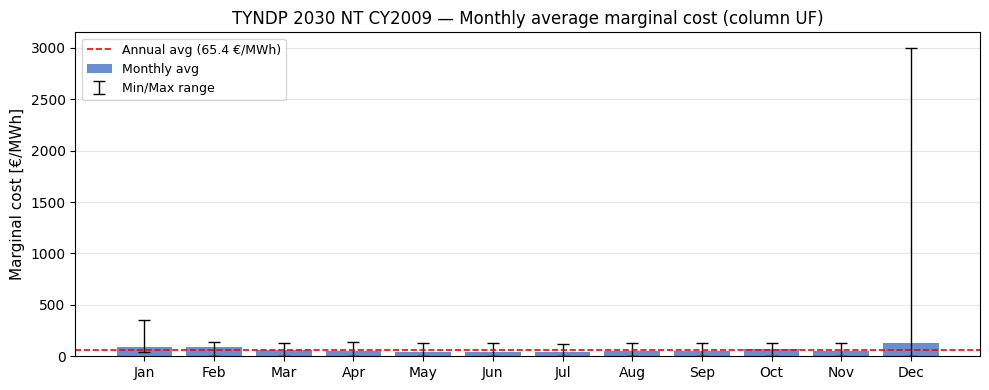

In [75]:

# Monthly average marginal cost 
df = df.set_index("timestamp").sort_index()
df["marginal_cost"] = pd.to_numeric(df["marginal_cost"], errors="coerce")

monthly = df["marginal_cost"].resample("ME").agg(["mean", "min", "max", "count"])
monthly.index = monthly.index.strftime("%b")

print("=== TYNDP 2030 NT CY2009 — Monthly Marginal Cost (column UF) ===")
print(f"  {'Month':<5} {'Avg €/MWh':>10} {'Min €/MWh':>10} {'Max €/MWh':>10} {'Hours':>7}")
print("  " + "─" * 46)
for m, row in monthly.iterrows():
    print(f"  {m:<5} {row['mean']:>10.2f} {row['min']:>10.2f} {row['max']:>10.2f} {row['count']:>7.0f}")

print(f"\n  Annual average: {df['marginal_cost'].mean():.2f} €/MWh")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(monthly))
ax.bar(x, monthly["mean"], color="#4472c4", alpha=0.8, label="Monthly avg")
ax.errorbar(x, monthly["mean"],
            yerr=[monthly["mean"] - monthly["min"], monthly["max"] - monthly["mean"]],
            fmt="none", color="black", capsize=4, linewidth=1, label="Min/Max range")
ax.axhline(df["marginal_cost"].mean(), color="red", linestyle="--", linewidth=1.2,
           label=f"Annual avg ({df['marginal_cost'].mean():.1f} €/MWh)")
ax.set_xticks(list(x))
ax.set_xticklabels(monthly.index)
ax.set_ylabel("Marginal cost [€/MWh]", fontsize=11)
ax.set_title("TYNDP 2030 NT CY2009 — Monthly average marginal cost (column UF)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Month   Avg €/MWh  Min €/MWh  Max €/MWh
----------------------------------------
  Jan       86.76       5.00     564.00
  Feb       79.34       1.43     183.51
  Mar       62.18       0.01     150.00
  Apr       54.00       0.01      84.86
  May       34.80       0.01      79.85
  Jun       42.91       0.01      82.32
  Jul       41.79       0.01      82.32
  Aug       54.28       0.01      82.32
  Sep       52.79       0.01      84.86
  Oct       65.40       1.24     126.72
  Nov       51.87       1.43     115.00
  Dec      114.98       1.43    3000.00
  

Month       Model     TYNDP 2030 NT CY2009    Difference    Difference in %
----------------------------------------------------------------------------
  Jan       86.76     92.23                   -5.47         -5.93%
  Feb       79.34     86.31                   -6.97         -8.08%
  Mar       62.18     65.29                   -3.11         -4.76%
  Apr       54.00     55.50                   -1.50         -2.70%
  May       34.80     37.64                   -2.84         -7.55%
  Jun       42.91     46.28                   -3.37         -7.28%
  Jul       41.79     44.58                   -2.79         -6.26%
  Aug       54.28     53.28                   +1.00         +1.88%
  Sep       52.79     50.65                   +2.14         +4.22%
  Oct       65.40     68.81                   -3.41         -4.95%
  Nov       51.87     54.83                   -2.96         -5.40%
  Dec      114.98     132.44                  -17.46        -13.18%



Month       Model     TYNDP 2030 NT CY2009    Difference    Difference in %
----------------------------------------------------------------------------
  Jan       86.45     92.23                   -5.78        -6.27%
  Feb       79.52     86.31                   -6.79        -7.87%
  Mar       61.00     65.29                   -4.29        -6.57%
  Apr       52.11     55.50                   -3.39        -6.11%
  May       29.75     37.64                   -7.89        -20.95%
  Jun       37.20     46.28                   -9.08        -19.61%
  Jul       36.67     44.58                   -7.91        -17.74%
  Aug       47.85     53.28                   -5.43        -10.19%
  Sep       51.25     50.65                    0.60         1.18%
  Oct       63.98     68.81                   -4.83        -7.02%
  Nov       50.65     54.83                   -4.18        -7.63%
  Dec      114.67     132.44                   -17.77       -13.42%


Month       Model     TYNDP 2030 NT CY2009    Market
----------------------------------------------------
  Jan       86.45     92.23                   84.6        
  Feb       79.52     86.31                   81.8        
  Mar       61.00     65.29                   67.5        
  Apr       52.11     55.50                   60.3        
  May       29.75     37.64                   55.7        
  Jun       37.20     46.28                   57.6        
  Jul       36.67     44.58                   62.6        
  Aug       47.85     53.28                   65.2        
  Sep       51.25     50.65                   70.5        
  Oct       63.98     68.81                   70.3        
  Nov       50.65     54.83                   80.1        
  Dec      114.67     132.44                  77.7       


Month   Avg €/MWh  Min €/MWh  Max €/MWh
----------------------------------------
  Jan       86.45       5.00     515.46
  Feb       79.52       1.43     200.00
  Mar       61.00       0.01     152.42
  Apr       52.11       0.01      84.86
  May       29.75       0.01      79.85
  Jun       37.20       0.01      79.85
  Jul       36.67       0.01      82.32
  Aug       47.85       0.01      82.32
  Sep       51.25       0.01      82.32
  Oct       63.98       1.24     126.72
  Nov       50.65       1.43     125.38
  Dec      114.67       1.43    3000.00    


In [76]:

# Load network and TYNDP data — shared across all cells below

import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

XLSX = "../data/tyndp2024/MMStandardOutputFile_NT2030_Plexos_CY2009_2.5_v40 3.xlsx"
NETWORK_FILE = "../solved_networks/tyndp2024_network_2030_slack_optimized_26.nc"
MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

network = pypsa.Network(NETWORK_FILE)
model_prices = network.buses_t.marginal_price.copy()
print(f"Model loaded: {model_prices.shape[1]} zones, {model_prices.shape[0]} hours")


INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks


Model loaded: 55 zones, 8760 hours


In [77]:

# Read TYNDP marginal costs for all zones from XLSX
# Rows 10/11/12 (0-indexed) contain Category / Country / Code

meta = pd.read_excel(XLSX, sheet_name="Hourly Market Data", header=None, nrows=13, engine="openpyxl")
row_cat     = meta.iloc[10]  # category name e.g. "MARGINAL COST [€]"
row_country = meta.iloc[11]  # zone code e.g. "DE00"

mc_col_map = {}  # zone -> 0-based column index
for idx in range(len(row_cat)):
    if "MARGINAL" in str(row_cat[idx]).upper():
        mc_col_map[str(row_country[idx])] = idx

print(f"TYNDP marginal cost columns found: {len(mc_col_map)} zones")

# Read only marginal cost columns + timestamp column
usecols = [1] + list(mc_col_map.values())
tyndp_raw = pd.read_excel(
    XLSX,
    sheet_name="Hourly Market Data",
    header=None,
    skiprows=13,
    usecols=usecols,
    engine="openpyxl",
)
tyndp_raw.columns = ["ts_str"] + list(mc_col_map.keys())
tyndp_raw = tyndp_raw.dropna(subset=["ts_str"])

# Parse timestamps — format: "01JAN00:00"
def parse_tyndp_ts(s):
    try:
        s = str(s).strip()
        return pd.Timestamp(f"2030-{s[2:5].capitalize()}-{s[:2]} {s[5:7]}:{s[8:10] if len(s) >= 10 else '00'}")
    except Exception:
        return pd.NaT

tyndp_raw["timestamp"] = tyndp_raw["ts_str"].apply(parse_tyndp_ts)
n_bad = tyndp_raw["timestamp"].isna().sum()
print(f"Timestamp parse: OK={len(tyndp_raw) - n_bad}  Failed={n_bad}")

tyndp_prices = (
    tyndp_raw.dropna(subset=["timestamp"])
    .set_index("timestamp")
    .drop(columns=["ts_str"])
    .apply(pd.to_numeric, errors="coerce")
)
print(f"TYNDP data shape: {tyndp_prices.shape}  (rows=hours, cols=zones)")


TYNDP marginal cost columns found: 77 zones
Timestamp parse: OK=8736  Failed=0
TYNDP data shape: (8736, 77)  (rows=hours, cols=zones)


In [78]:

# Build per-zone monthly comparison table (Model vs TYNDP)

common_zones = sorted(set(tyndp_prices.columns) & set(model_prices.columns))
only_tyndp   = sorted(set(tyndp_prices.columns) - set(model_prices.columns))
only_model   = sorted(set(model_prices.columns) - set(tyndp_prices.columns))
print(f"Common zones : {len(common_zones)}")
print(f"Only in TYNDP: {len(only_tyndp)}  {only_tyndp}")
print(f"Only in model: {len(only_model)}  {only_model}")

records = []  # will hold one row per (zone, month)

for zone in common_zones:
    tyndp_m = tyndp_prices[zone].resample("ME").mean()
    tyndp_m.index = tyndp_m.index.strftime("%b")

    model_m = model_prices[zone].resample("ME").mean()
    model_m.index = model_m.index.strftime("%b")

    tyndp_min = tyndp_prices[zone].resample("ME").min()
    tyndp_min.index = tyndp_min.index.strftime("%b")
    tyndp_max = tyndp_prices[zone].resample("ME").max()
    tyndp_max.index = tyndp_max.index.strftime("%b")
    model_min = model_prices[zone].resample("ME").min()
    model_min.index = model_min.index.strftime("%b")
    model_max = model_prices[zone].resample("ME").max()
    model_max.index = model_max.index.strftime("%b")

    for mon in MONTH_NAMES:
        if mon in tyndp_m.index and mon in model_m.index:
            t_val = tyndp_m[mon]
            m_val = model_m[mon]
            diff  = m_val - t_val
            pct   = 100 * diff / t_val if t_val != 0 else np.nan
            records.append({
                "zone": zone, "month": mon,
                "model": m_val, "model_min": model_min.get(mon, np.nan), "model_max": model_max.get(mon, np.nan),
                "tyndp": t_val, "tyndp_min": tyndp_min.get(mon, np.nan), "tyndp_max": tyndp_max.get(mon, np.nan),
                "diff": diff, "diff_pct": pct,
            })

summary_df = pd.DataFrame(records)
print(f"\nBuilt summary_df: {len(summary_df)} rows  ({len(common_zones)} zones × 12 months)")


Common zones : 51
Only in TYNDP: 26  ['BEOF', 'DEKF', 'DKBH', 'DKKF', 'DKNS', 'DZ00', 'EEOF', 'EG00', 'GE00', 'IL00', 'IS00', 'LTOF', 'LY00', 'MA00', 'MD00', 'NL60', 'NL6H', 'NLA0', 'NLBH', 'NLLL', 'PS00', 'TN00', 'TR00', 'UA00', 'UK00', 'UKNI']
Only in model: 4  ['GB00', 'GBNI', 'ITCO', 'ITVI']

Built summary_df: 612 rows  (51 zones × 12 months)


In [79]:

# Print per-zone monthly comparison tables

for zone in common_zones:
    z_df = summary_df[summary_df["zone"] == zone]
    ann_model = model_prices[zone].mean()
    ann_tyndp = tyndp_prices[zone].mean()
    ann_diff  = ann_model - ann_tyndp
    ann_pct   = 100 * ann_diff / ann_tyndp if ann_tyndp != 0 else float("nan")

    print(f"\n{zone}  (Annual — Model: {ann_model:.1f}  TYNDP: {ann_tyndp:.1f}  Diff: {ann_diff:+.1f}  {ann_pct:+.1f}%)")
    print(f"  {'Month':<5}  {'Model Avg':>10}  {'Min':>7}  {'Max':>7}  {'TYNDP Avg':>10}  {'Min':>7}  {'Max':>7}  {'Diff':>8}  {'Diff%':>7}")
    print("  " + "-" * 80)
    for _, row in z_df.iterrows():
        flag = " ⚠" if abs(row["diff_pct"]) > 15 else ""
        print(
            f"  {row['month']:<5}  {row['model']:>10.2f}  {row['model_min']:>7.2f}  {row['model_max']:>7.2f}"
            f"  {row['tyndp']:>10.2f}  {row['tyndp_min']:>7.2f}  {row['tyndp_max']:>7.2f}"
            f"  {row['diff']:>+8.2f}  {row['diff_pct']:>+6.1f}%{flag}"
        )



AL00  (Annual — Model: 76.1  TYNDP: 83.0  Diff: -6.9  -8.3%)
  Month   Model Avg      Min      Max   TYNDP Avg      Min      Max      Diff    Diff%
  --------------------------------------------------------------------------------
  Jan         77.73    77.45    79.85       83.42    81.66   104.39     -5.69    -6.8%
  Feb         77.41    68.74    79.85       83.06    73.84    93.90     -5.64    -6.8%
  Mar         75.49    21.65    77.45       81.24    43.49    96.14     -5.75    -7.1%
  Apr         71.60    21.65    77.45       81.53    43.08    92.92     -9.93   -12.2%
  May         74.80    22.32    77.45       83.54    46.77    97.67     -8.74   -10.5%
  Jun         75.66    24.45    77.45       83.63    66.27    91.51     -7.97    -9.5%
  Jul         75.82    43.65    77.45       83.01    65.28    97.25     -7.19    -8.7%
  Aug         77.15    64.68    77.45       84.08    67.38    96.19     -6.92    -8.2%
  Sep         76.30    43.65    77.45       83.03    65.05    92.58     

In [80]:

# Network-wide summary — load-weighted average across all common zones

load_by_zone = {}
for zone in common_zones:
    zone_load_cols = network.loads[network.loads.bus == zone].index
    avail = [c for c in zone_load_cols if c in network.loads_t.p_set.columns]
    load_by_zone[zone] = network.loads_t.p_set[avail].sum().sum() if avail else 1.0

total_weight = sum(load_by_zone.values())
weights = {z: w / total_weight for z, w in load_by_zone.items()}

network_records = []
for mon in MONTH_NAMES:
    mon_df = summary_df[summary_df["month"] == mon].set_index("zone")
    w_arr   = np.array([weights.get(z, 0) for z in mon_df.index])
    w_arr   = w_arr / w_arr.sum()
    w_model = np.dot(w_arr, mon_df["model"].values)
    w_tyndp = np.dot(w_arr, mon_df["tyndp"].values)
    diff    = w_model - w_tyndp
    pct     = 100 * diff / w_tyndp if w_tyndp != 0 else float("nan")
    network_records.append({"month": mon, "model": w_model, "tyndp": w_tyndp, "diff": diff, "diff_pct": pct})

nw_df = pd.DataFrame(network_records)

print("NETWORK-WIDE SUMMARY — load-weighted average over all common zones")
print(f"  {'Month':<5}  {'Model':>10}  {'TYNDP':>10}  {'Diff':>10}  {'Diff%':>8}")
print("  " + "-" * 48)
for _, row in nw_df.iterrows():
    flag = " ⚠" if abs(row["diff_pct"]) > 15 else ""
    print(f"  {row['month']:<5}  {row['model']:>10.2f}  {row['tyndp']:>10.2f}  {row['diff']:>+10.2f}  {row['diff_pct']:>+7.1f}%{flag}")

ann_model = nw_df["model"].mean()
ann_tyndp = nw_df["tyndp"].mean()
ann_diff  = ann_model - ann_tyndp
print(f"\n  Annual avg (load-weighted, monthly mean):")
print(f"    Model : {ann_model:.2f} €/MWh")
print(f"    TYNDP : {ann_tyndp:.2f} €/MWh")
print(f"    Diff  : {ann_diff:+.2f} €/MWh  ({100*ann_diff/ann_tyndp:+.1f}%)")


NETWORK-WIDE SUMMARY — load-weighted average over all common zones
  Month       Model       TYNDP        Diff     Diff%
  ------------------------------------------------
  Jan         72.57       79.66       -7.10     -8.9%
  Feb         69.66       78.10       -8.45    -10.8%
  Mar         58.27       62.33       -4.07     -6.5%
  Apr         51.62       55.37       -3.75     -6.8%
  May         42.58       47.50       -4.92    -10.4%
  Jun         49.18       54.20       -5.02     -9.3%
  Jul         48.70       53.45       -4.75     -8.9%
  Aug         54.76       58.17       -3.41     -5.9%
  Sep         51.86       54.92       -3.06     -5.6%
  Oct         60.47       65.57       -5.10     -7.8%
  Nov         53.02       57.04       -4.02     -7.0%
  Dec         78.43       88.93      -10.50    -11.8%

  Annual avg (load-weighted, monthly mean):
    Model : 57.59 €/MWh
    TYNDP : 62.94 €/MWh
    Diff  : -5.34 €/MWh  (-8.5%)


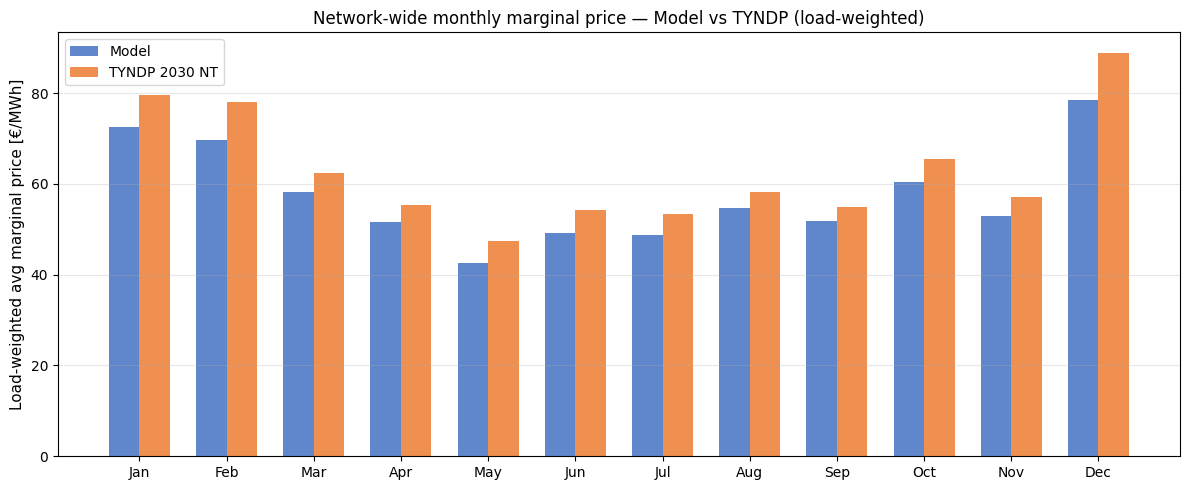

In [81]:

# Network-wide bar chart: Model vs TYNDP monthly averages

fig, ax = plt.subplots(figsize=(12, 5))
x = range(12)
w = 0.35
ax.bar([i - w/2 for i in x], nw_df["model"], width=w, color="#4472c4", label="Model", alpha=0.85)
ax.bar([i + w/2 for i in x], nw_df["tyndp"],  width=w, color="#ed7d31", label="TYNDP 2030 NT", alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel("Load-weighted avg marginal price [€/MWh]", fontsize=11)
ax.set_title("Network-wide monthly marginal price — Model vs TYNDP (load-weighted)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
